<a href="https://colab.research.google.com/github/vardhan999505/AIDriven-Archaeological-Site-Mapping/blob/main/Milestone3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏛️ AI-Driven Archaeological Site Mapping
## Milestone 3 — Terrain Erosion Prediction
**Weeks 5–6** | Feature Engineering → Random Forest → XGBoost → SHAP → Folium Map

**Datasets (processed in Milestone 1):**
- `vegetation_data set.v3i.coco-segmentation.zip` — COCO segmentation
- `Artifacts Dataset.v2i.yolov5pytorch.zip` — YOLOv5

> ⚠️ Run **Milestone 1** and **Milestone 2** fully before this notebook.
> Set Runtime → **GPU (T4)**


---
## 📦 Step 1 — Install Libraries

In [ ]:
!pip install -q xgboost scikit-learn shap
!pip install -q folium branca matplotlib seaborn tqdm
!pip install -q opencv-python-headless Pillow

import os,json,glob,random,shutil,warnings,pickle
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from pathlib import Path
from collections import Counter
import xgboost as xgb
import shap
import folium
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
warnings.filterwarnings('ignore')

SEED=42
random.seed(SEED); np.random.seed(SEED)
print('✅ All libraries loaded!')


✅ All libraries loaded!


---
## ☁️ Step 2 — Mount Drive & Connect to Milestone 1 & 2

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, json, glob, shutil
from pathlib import Path

# ── Dataset filenames (same as Milestone 1) ───────────────
# SEG: vegetation_data set.v3i.coco-segmentation.zip
# DET: Artifacts Dataset.v2i.yolov5pytorch.zip

DRIVE_BASE    = '/content/drive/MyDrive/Archaeological_AI'
DRIVE_PROJECT = f'{DRIVE_BASE}/project'
DRIVE_M2_OUT  = f'{DRIVE_BASE}/Milestone2_Output'
BASE_DIR      = '/content/archaeological_project'

def restore_from_drive(drive_src, local_dst):
    if not os.path.exists(drive_src): return 0
    os.makedirs(local_dst, exist_ok=True)
    count = 0
    for item in Path(drive_src).rglob('*'):
        if item.is_file():
            rel  = item.relative_to(drive_src)
            dest = Path(local_dst) / rel
            dest.parent.mkdir(parents=True, exist_ok=True)
            if not dest.exists():
                shutil.copy2(item, dest); count += 1
    return count

print('Restoring outputs from Drive...')
r1 = restore_from_drive(f'{DRIVE_PROJECT}/split/segmentation', f'{BASE_DIR}/split/segmentation')
r2 = restore_from_drive(f'{DRIVE_PROJECT}/split/detection',    f'{BASE_DIR}/split/detection')
r3 = restore_from_drive(f'{DRIVE_PROJECT}/processed',          f'{BASE_DIR}/processed')
r4 = restore_from_drive(DRIVE_M2_OUT,                          f'{BASE_DIR}/milestone2_output')
print(f'  split/segmentation : {r1} files')
print(f'  split/detection    : {r2} files')
print(f'  processed/         : {r3} files')
print(f'  M2 outputs/        : {r4} files')

# ── Path variables ────────────────────────────────────────
SEG_SPLIT_DIR = f'{BASE_DIR}/split/segmentation'
DET_SPLIT_DIR = f'{BASE_DIR}/split/detection'
META_PATH     = f'{BASE_DIR}/processed/milestone1_metadata.json'

# ── Find seg model — search all possible locations ────────
# M2 saves to Milestone2_Output/ (flat) AND project/milestone2/...
SEG_MODEL_CANDIDATES = [
    f'{BASE_DIR}/milestone2_output/best_seg_model.pth',
    f'{BASE_DIR}/milestone2/segmentation/checkpoints/best_seg_model.pth',
    f'{BASE_DIR}/milestone2_output/segmentation/checkpoints/best_seg_model.pth',
]
SEG_MODEL_PATH = None
for candidate in SEG_MODEL_CANDIDATES:
    if os.path.exists(candidate):
        SEG_MODEL_PATH = candidate
        break
# Also scan Drive directly if not found locally
if SEG_MODEL_PATH is None:
    found = glob.glob(f'{DRIVE_BASE}/**/*best_seg_model.pth', recursive=True)
    if found:
        # Copy to local
        os.makedirs(f'{BASE_DIR}/milestone2_output', exist_ok=True)
        shutil.copy2(found[0], f'{BASE_DIR}/milestone2_output/best_seg_model.pth')
        SEG_MODEL_PATH = f'{BASE_DIR}/milestone2_output/best_seg_model.pth'
        print(f'  Recovered seg model from Drive: {found[0]}')

# ── M3 output dirs ────────────────────────────────────────
M3_DIR      = f'{BASE_DIR}/milestone3'
FEAT_DIR    = f'{M3_DIR}/features'
MODEL_DIR   = f'{M3_DIR}/models'
RESULTS_DIR = f'{M3_DIR}/results'
MAP_DIR     = f'{M3_DIR}/maps'
for d in [FEAT_DIR, MODEL_DIR, RESULTS_DIR, MAP_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Verify ────────────────────────────────────────────────
print('\nVerifying outputs...')
checks = {
    'Seg split (M1)'  : SEG_SPLIT_DIR,
    'Det split (M1)'  : DET_SPLIT_DIR,
    'Metadata (M1)'   : META_PATH,
    'Seg weights (M2)': SEG_MODEL_PATH or 'NOT FOUND',
}
all_ok = True
for name, path in checks.items():
    exists = os.path.exists(path)
    print(f'  {"✅" if exists else "❌"} {name}')
    if not exists: all_ok = False

if os.path.exists(META_PATH):
    with open(META_PATH) as f: meta = json.load(f)
    SEG_CLASSES = meta['segmentation']['categories']
    IMG_SIZE    = tuple(meta['target_img_size'])
    print(f'\n✅ Metadata loaded!')
    print(f'   Seg classes: {SEG_CLASSES}  Image size: {IMG_SIZE}')
else:
    SEG_CLASSES = ['vegetation', 'ruins', 'erosion']
    IMG_SIZE    = (640, 640)
    print('⚠️  Using defaults')

if SEG_MODEL_PATH is None or not os.path.exists(SEG_MODEL_PATH):
    print('\n⚠️  Seg weights missing — M3 will still run (erosion model does not need it).')
    print('   To fix: make sure M2 last cell completed (best_seg_model.pth → Drive).')
else:
    print(f'   Seg model: {SEG_MODEL_PATH}')

print('\n✅ M3 directories ready!')


Mounted at /content/drive
Restoring outputs from Drive...
  split/segmentation : 440 files
  split/detection    : 50 files
  processed/         : 7 files
  M2 outputs/        : 8 files

Verifying outputs...
  ✅ Seg split (M1)
  ✅ Det split (M1)
  ✅ Metadata (M1)
  ✅ Seg weights (M2)

✅ Metadata loaded!
   Seg classes: ['ruins-vegetation', 'vegetation']  Image size: (640, 640)
   Seg model: /content/archaeological_project/milestone2_output/best_seg_model.pth

✅ M3 directories ready!


---
## 🌍 Step 3 — Feature Extraction Function

In [ ]:
def extract_terrain_features(img_path):
    """
    Extract 13 terrain features from one RGB image patch.
    Returns dict of feature_name → float, or None if image unreadable.
    """
    img_bgr=cv2.imread(str(img_path))
    if img_bgr is None: return None
    img_bgr=cv2.resize(img_bgr,(256,256))
    img_rgb=cv2.cvtColor(img_bgr,cv2.COLOR_BGR2RGB).astype(np.float32)
    gray   =cv2.cvtColor(img_bgr,cv2.COLOR_BGR2GRAY).astype(np.float32)
    img_hsv=cv2.cvtColor(img_bgr,cv2.COLOR_BGR2HSV).astype(np.float32)
    R,G,B  =img_rgb[:,:,0],img_rgb[:,:,1],img_rgb[:,:,2]

    # Slope proxy (Sobel gradient magnitude)
    sx=cv2.Sobel(gray,cv2.CV_32F,1,0,ksize=3)
    sy=cv2.Sobel(gray,cv2.CV_32F,0,1,ksize=3)
    grad=np.sqrt(sx**2+sy**2)
    slope_mean=float(grad.mean()); slope_std=float(grad.std()); slope_max=float(grad.max())

    # Aspect (slope direction)
    angle=float(np.arctan2(sy.mean(),sx.mean()+1e-8))
    aspect_sin=float(np.sin(angle)); aspect_cos=float(np.cos(angle))

    # NDVI proxy (vegetation index using RGB)
    ndvi=(G-R)/(G+R+1e-6)
    ndvi_mean=float(ndvi.mean()); ndvi_std=float(ndvi.std())

    # Elevation proxy (brightness)
    elev_mean=float(gray.mean()/255.0); elev_std=float(gray.std()/255.0)

    # Texture (Laplacian variance = surface roughness)
    texture=float(cv2.Laplacian(gray,cv2.CV_32F).var())

    # Vegetation cover (green HSV pixels)
    hue=img_hsv[:,:,0]; sat=img_hsv[:,:,1]
    veg_mask=((hue>35)&(hue<85)&(sat>40)).astype(np.float32)
    veg_cover=float(veg_mask.mean())

    # Bare soil ratio (brownish low-sat)
    soil_mask=((hue>10)&(hue<35)&(sat<120)).astype(np.float32)
    soil_ratio=float(soil_mask.mean())

    # Water body (blue dominance)
    water_mask=((B>R+15)&(B>G+5)).astype(np.float32)
    water_ratio=float(water_mask.mean())

    return {'slope_mean':slope_mean,'slope_std':slope_std,'slope_max':slope_max,
            'aspect_sin':aspect_sin,'aspect_cos':aspect_cos,
            'ndvi_mean':ndvi_mean,'ndvi_std':ndvi_std,
            'elev_mean':elev_mean,'elev_std':elev_std,
            'texture':texture,'veg_cover':veg_cover,
            'soil_ratio':soil_ratio,'water_ratio':water_ratio}

print('✅ Feature extraction function defined!')
print('   Features per image: 13 terrain measurements')


✅ Feature extraction function defined!
   Features per image: 13 terrain measurements


---
## 🗂️ Step 4 — Extract Features from All Images

In [ ]:
IMG_EXTS=('.jpg','.jpeg','.png','.bmp')

def collect_images(root):
    return [f for f in glob.glob(f'{root}/**/*',recursive=True)
            if f.lower().endswith(IMG_EXTS)]

all_img_paths=[]
for split in ['train','val','test']:
    sp=collect_images(f'{SEG_SPLIT_DIR}/{split}')
    all_img_paths.extend(sp)
    print(f'  {split:<8}: {len(sp)} images')
print(f'\nTotal: {len(all_img_paths)} images to process')

records=[]; failed=0
for p in tqdm(all_img_paths,desc='Extracting features'):
    feats=extract_terrain_features(p)
    if feats is None: failed+=1; continue
    feats['image_path']=str(p); feats['image_name']=Path(p).stem
    records.append(feats)

df=pd.DataFrame(records)
print(f'\n✅ Feature extraction complete!')
print(f'   Processed : {len(df)}  Failed: {failed}')
print(f'   Features  : {len(df.columns)-2}')
print(df.drop(columns=['image_path','image_name']).describe().round(4))


  train   : 306 images
  val     : 87 images
  test    : 44 images

Total: 437 images to process


Extracting features: 100%|██████████| 437/437 [00:03<00:00, 118.30it/s]


✅ Feature extraction complete!
   Processed : 437  Failed: 0
   Features  : 13
       slope_mean  slope_std  slope_max  aspect_sin  aspect_cos  ndvi_mean  \
count    437.0000   437.0000   437.0000    437.0000    437.0000   437.0000   
mean      55.7263    45.6887   424.2538      0.0186      0.0214     0.1324   
std       21.5523    16.0887   137.8576      0.7336      0.6807     0.0789   
min        9.6712    12.0151   108.8485     -0.9998     -0.9998    -0.0697   
25%       33.9477    37.4543   325.2076     -0.7460     -0.6862     0.0824   
50%       60.6910    46.9950   415.7162      0.0659      0.1159     0.1477   
75%       72.6534    55.5739   541.1562      0.7826      0.6210     0.1923   
max      102.9012    86.8051   755.3224      1.0000      1.0000     0.3246   

       ndvi_std  elev_mean  elev_std    texture  veg_cover  soil_ratio  \
count  437.0000   437.0000  437.0000   437.0000   437.0000    437.0000   
mean     0.0935     0.2755    0.0886   460.7297     0.7676      0.179

---
## 🏷️ Step 5 — Generate Erosion Risk Labels

In [ ]:
def compute_erosion_label(row):
    score=0.0
    score+=0.35*min(row['slope_mean']/50.0,1.0)          # steep = risky
    score+=0.30*max(0.0,1.0-(row['ndvi_mean']+1.0)/2.0)  # no veg = risky
    score+=0.20*min(row['soil_ratio']*3.0,1.0)            # bare soil = risky
    score+=0.10*max(0.0,1.0-row['veg_cover']*2.0)         # low cover = risky
    score-=0.05*min(row['water_ratio']*5.0,1.0)           # water reduces risk
    score+=0.10*min(row['texture']/500.0,1.0)             # rough terrain = risky
    score=float(np.clip(score,0.0,1.0))
    cls=0 if score<0.35 else (1 if score<0.65 else 2)
    return score,cls

res=[compute_erosion_label(row) for _,row in df.iterrows()]
df['erosion_score']=[r[0] for r in res]
df['erosion_class']=[r[1] for r in res]
df['erosion_label']=df['erosion_class'].map({0:'low',1:'medium',2:'high'})

print('✅ Erosion labels generated!')
print('\nClass distribution:')
print(df['erosion_label'].value_counts())
print(f'\nErosion score: mean={df["erosion_score"].mean():.3f}  '
      f'std={df["erosion_score"].std():.3f}  '
      f'min={df["erosion_score"].min():.3f}  '
      f'max={df["erosion_score"].max():.3f}')

df_path=f'{FEAT_DIR}/terrain_features.csv'
df.to_csv(df_path,index=False)
print(f'\n✅ Feature dataset saved: {df_path}')


✅ Erosion labels generated!

Class distribution:
erosion_label
medium    209
high      156
low        72
Name: count, dtype: int64

Erosion score: mean=0.583  std=0.171  min=0.182  max=0.871

✅ Feature dataset saved: /content/archaeological_project/milestone3/features/terrain_features.csv


---
## 📊 Step 6 — EDA & Correlation Heatmap

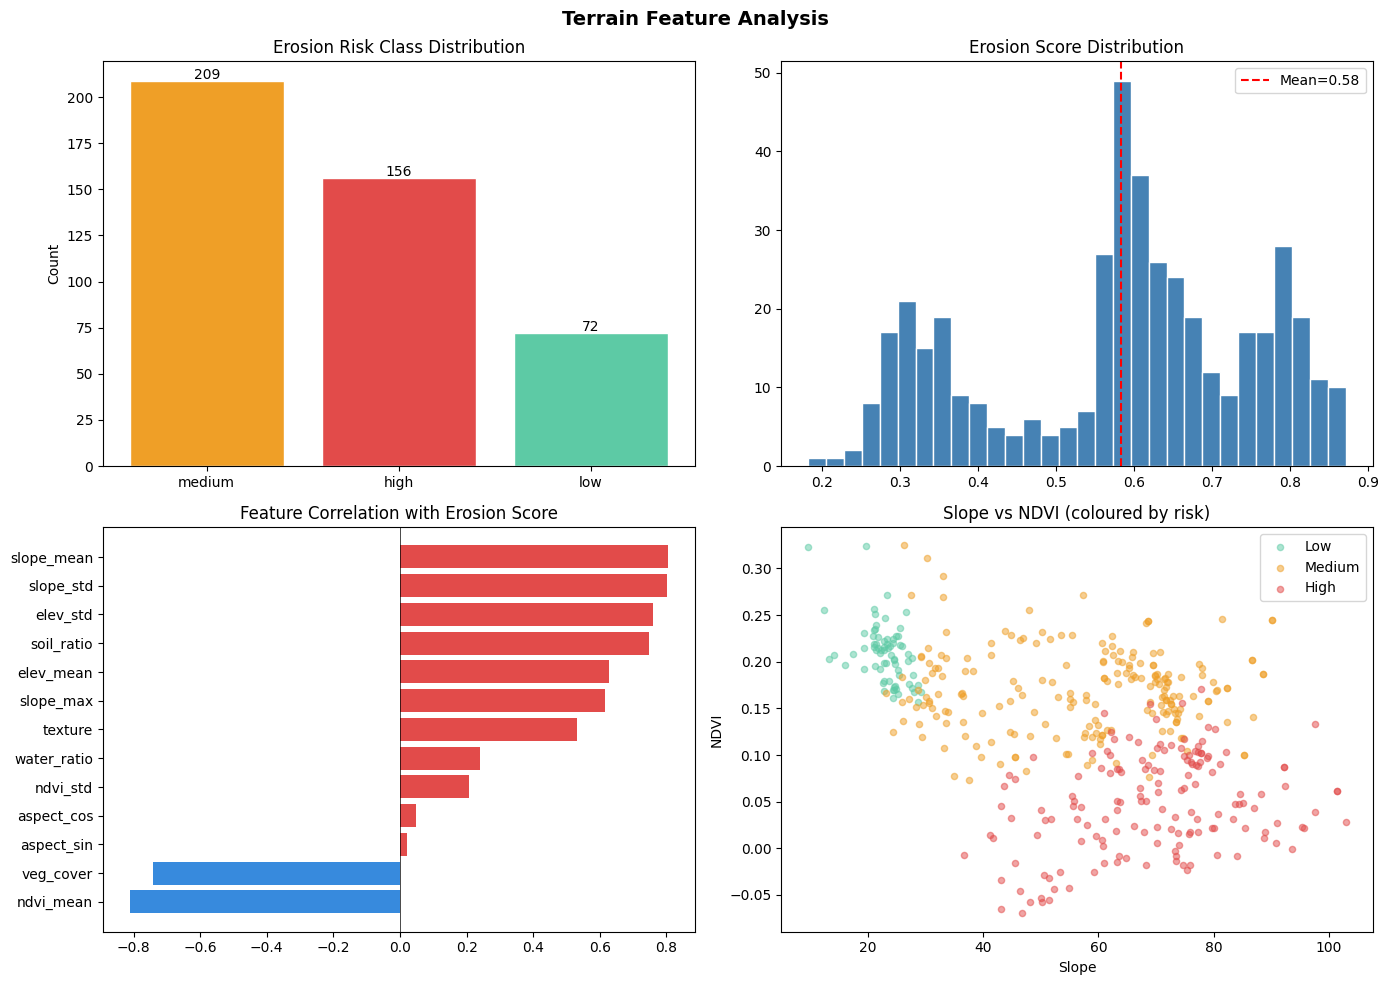

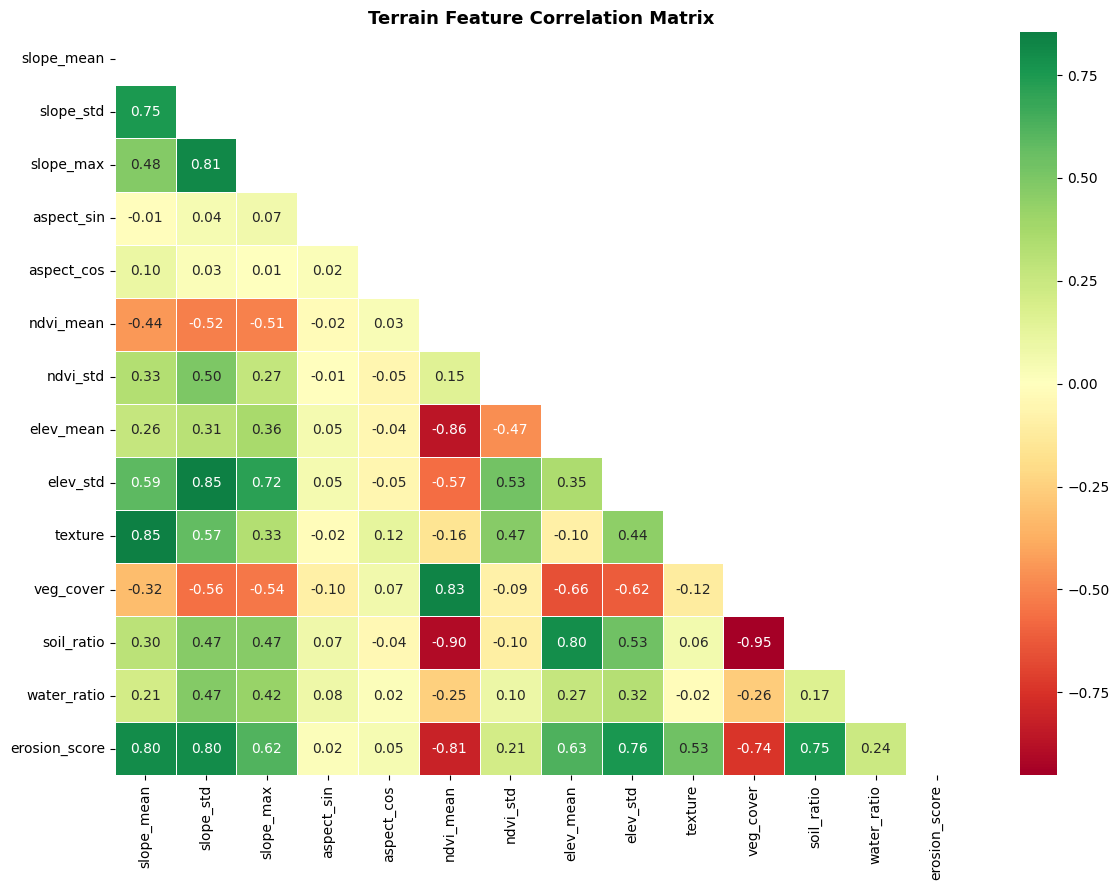

✅ EDA & heatmap saved!


In [ ]:
FEATURE_COLS=['slope_mean','slope_std','slope_max','aspect_sin','aspect_cos',
               'ndvi_mean','ndvi_std','elev_mean','elev_std',
               'texture','veg_cover','soil_ratio','water_ratio']

fig,axes=plt.subplots(2,2,figsize=(14,10))
fig.suptitle('Terrain Feature Analysis',fontsize=14,fontweight='bold')

colors={'low':'#5DCAA5','medium':'#EF9F27','high':'#E24B4A'}
counts=df['erosion_label'].value_counts()
axes[0,0].bar(counts.index,counts.values,color=[colors[l] for l in counts.index],edgecolor='white')
axes[0,0].set_title('Erosion Risk Class Distribution'); axes[0,0].set_ylabel('Count')
for i,(k,v) in enumerate(counts.items()): axes[0,0].text(i,v+1,str(v),ha='center',fontsize=10)

axes[0,1].hist(df['erosion_score'],bins=30,color='steelblue',edgecolor='white')
axes[0,1].axvline(df['erosion_score'].mean(),color='red',linestyle='--',
                  label=f'Mean={df["erosion_score"].mean():.2f}')
axes[0,1].set_title('Erosion Score Distribution'); axes[0,1].legend()

corrs=df[FEATURE_COLS].corrwith(df['erosion_score']).sort_values()
bar_c=['#E24B4A' if v>0 else '#378ADD' for v in corrs.values]
axes[1,0].barh(corrs.index,corrs.values,color=bar_c)
axes[1,0].set_title('Feature Correlation with Erosion Score')
axes[1,0].axvline(0,color='black',linewidth=0.5)

clr={0:'#5DCAA5',1:'#EF9F27',2:'#E24B4A'}
for cls,grp in df.groupby('erosion_class'):
    axes[1,1].scatter(grp['slope_mean'],grp['ndvi_mean'],c=clr[cls],
                     label=['Low','Medium','High'][cls],alpha=0.5,s=20)
axes[1,1].set_title('Slope vs NDVI (coloured by risk)')
axes[1,1].set_xlabel('Slope'); axes[1,1].set_ylabel('NDVI'); axes[1,1].legend()

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/eda_terrain.png',dpi=150,bbox_inches='tight')
plt.show()

# Heatmap
plt.figure(figsize=(12,9))
corr_matrix=df[FEATURE_COLS+['erosion_score']].corr()
mask=np.triu(np.ones_like(corr_matrix,dtype=bool))
sns.heatmap(corr_matrix,mask=mask,annot=True,fmt='.2f',cmap='RdYlGn',center=0,linewidths=0.5)
plt.title('Terrain Feature Correlation Matrix',fontsize=13,fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/correlation_heatmap.png',dpi=150,bbox_inches='tight')
plt.show()
print('✅ EDA & heatmap saved!')


---
## 🗃️ Step 7 — Train / Val / Test Split + Scaling

In [ ]:
X=df[FEATURE_COLS].values
y_reg=df['erosion_score'].values
y_cls=df['erosion_class'].values

imputer=SimpleImputer(strategy='median')
X=imputer.fit_transform(X)

X_train,X_test,y_reg_train,y_reg_test,y_cls_train,y_cls_test=train_test_split(
    X,y_reg,y_cls,test_size=0.20,random_state=SEED,stratify=y_cls)
X_train,X_val,y_reg_train,y_reg_val,y_cls_train,y_cls_val=train_test_split(
    X_train,y_reg_train,y_cls_train,test_size=0.15,random_state=SEED,stratify=y_cls_train)

scaler=StandardScaler()
X_train_s=scaler.fit_transform(X_train)
X_val_s  =scaler.transform(X_val)
X_test_s =scaler.transform(X_test)

print('✅ Data split complete!')
print(f'   Train : {X_train.shape[0]}  Val: {X_val.shape[0]}  Test: {X_test.shape[0]}')
print(f'   Features: {X_train.shape[1]}')
print('\nClass balance (train):')
u,c=np.unique(y_cls_train,return_counts=True)
for ui,ci in zip(u,c): print(f'   Class {ui} ({["low","medium","high"][ui]}): {ci} ({ci/len(y_cls_train)*100:.1f}%)')


✅ Data split complete!
   Train : 296  Val: 53  Test: 88
   Features: 13

Class balance (train):
   Class 0 (low): 48 (16.2%)
   Class 1 (medium): 142 (48.0%)
   Class 2 (high): 106 (35.8%)


---
## 🌲 Step 8 — Train Random Forest

In [ ]:
rf_model=RandomForestRegressor(n_estimators=200,max_depth=12,min_samples_split=4,
                                min_samples_leaf=2,max_features='sqrt',
                                n_jobs=-1,random_state=SEED,oob_score=True)
print('Training Random Forest (200 trees)...')
rf_model.fit(X_train_s,y_reg_train)

rf_val_pred =rf_model.predict(X_val_s)
rf_test_pred=rf_model.predict(X_test_s)
rf_val_rmse =float(np.sqrt(mean_squared_error(y_reg_val, rf_val_pred)))
rf_val_r2   =float(r2_score(y_reg_val,  rf_val_pred))
rf_test_rmse=float(np.sqrt(mean_squared_error(y_reg_test,rf_test_pred)))
rf_test_r2  =float(r2_score(y_reg_test, rf_test_pred))
rf_test_mae =float(mean_absolute_error(y_reg_test,rf_test_pred))

print(f'\n📊 Random Forest Results')
print(f'  Val  RMSE: {rf_val_rmse:.4f}  R²: {rf_val_r2:.4f}')
print(f'  Test RMSE: {rf_test_rmse:.4f}  R²: {rf_test_r2:.4f}  MAE: {rf_test_mae:.4f}')
print(f'  OOB Score: {rf_model.oob_score_:.4f}')


Training Random Forest (200 trees)...

📊 Random Forest Results
  Val  RMSE: 0.0222  R²: 0.9850
  Test RMSE: 0.0150  R²: 0.9920  MAE: 0.0105
  OOB Score: 0.9860


---
## ⚡ Step 9 — Train XGBoost

In [ ]:
xgb_model=xgb.XGBRegressor(n_estimators=300,max_depth=6,learning_rate=0.05,
                             subsample=0.8,colsample_bytree=0.8,
                             reg_alpha=0.1,reg_lambda=1.0,min_child_weight=3,gamma=0.1,
                             random_state=SEED,n_jobs=-1,verbosity=0,
                             eval_metric='rmse',early_stopping_rounds=20)
print('Training XGBoost (300 rounds with early stopping)...')
xgb_model.fit(X_train_s,y_reg_train,eval_set=[(X_val_s,y_reg_val)],verbose=50)

xgb_val_pred =xgb_model.predict(X_val_s)
xgb_test_pred=xgb_model.predict(X_test_s)
xgb_val_rmse =float(np.sqrt(mean_squared_error(y_reg_val, xgb_val_pred)))
xgb_val_r2   =float(r2_score(y_reg_val,  xgb_val_pred))
xgb_test_rmse=float(np.sqrt(mean_squared_error(y_reg_test,xgb_test_pred)))
xgb_test_r2  =float(r2_score(y_reg_test, xgb_test_pred))
xgb_test_mae =float(mean_absolute_error(y_reg_test,xgb_test_pred))

print(f'\n📊 XGBoost Results')
print(f'  Val  RMSE: {xgb_val_rmse:.4f}  R²: {xgb_val_r2:.4f}')
print(f'  Test RMSE: {xgb_test_rmse:.4f}  R²: {xgb_test_r2:.4f}  MAE: {xgb_test_mae:.4f}')


Training XGBoost (300 rounds with early stopping)...
[0]	validation_0-rmse:0.17430
[50]	validation_0-rmse:0.04158
[100]	validation_0-rmse:0.03884
[102]	validation_0-rmse:0.03884

📊 XGBoost Results
  Val  RMSE: 0.0388  R²: 0.9540
  Test RMSE: 0.0324  R²: 0.9624  MAE: 0.0241


---
## 📊 Step 10 — Model Comparison + Evaluation Plots

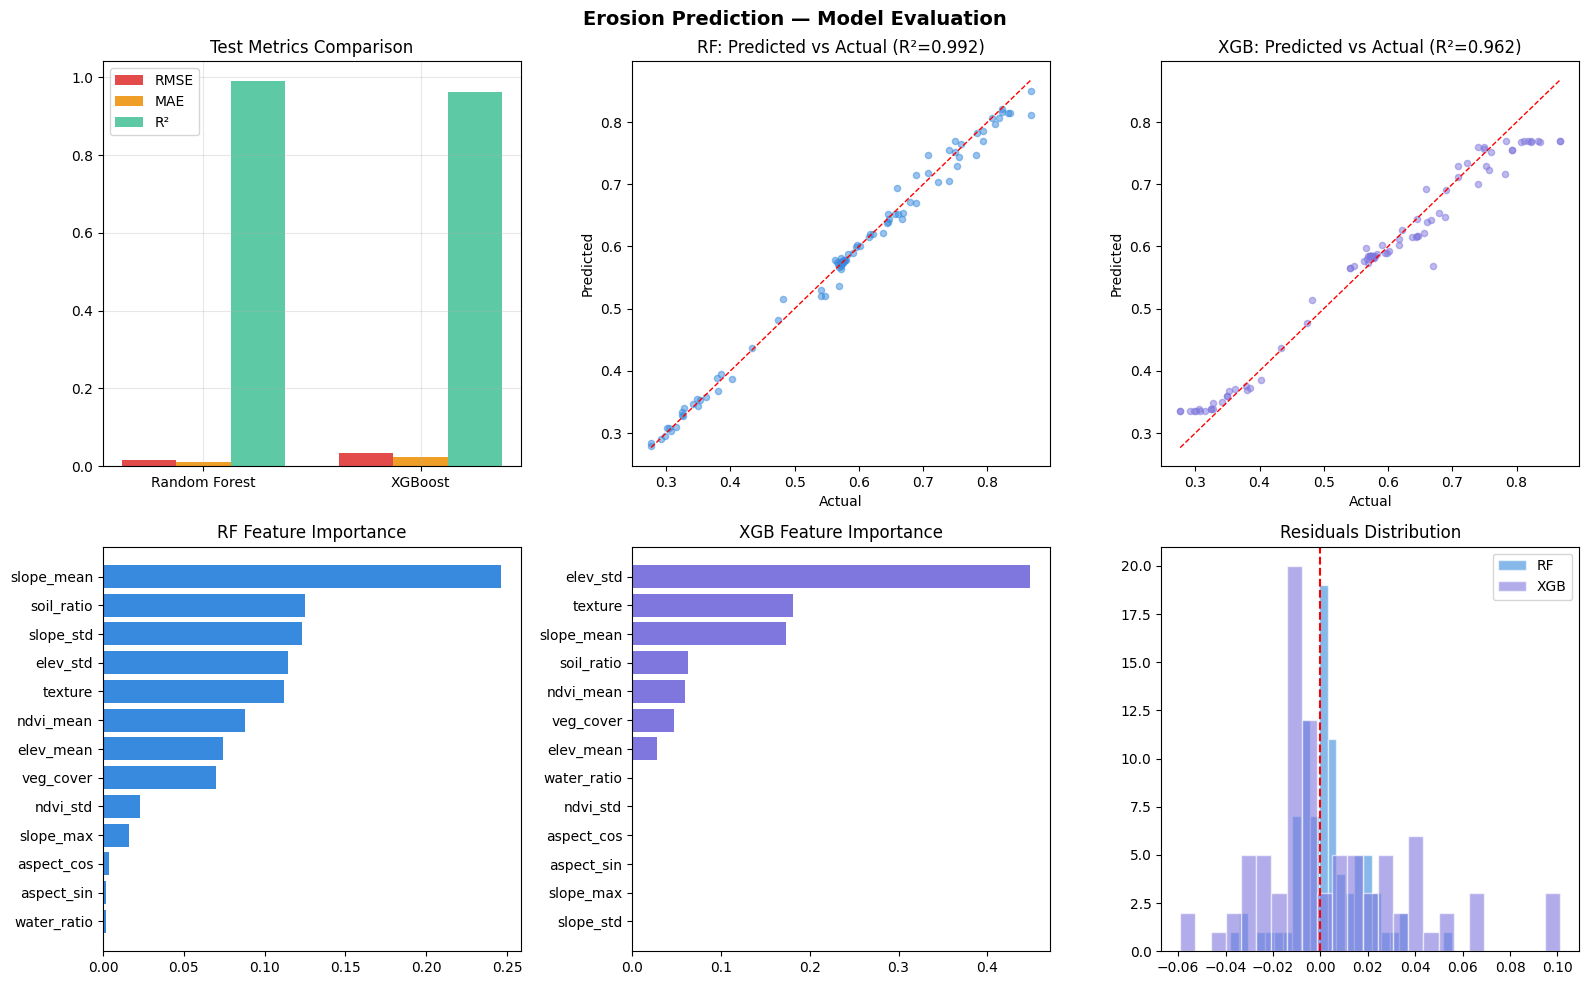

✅ Evaluation plots saved!

🏆 Best model: RandomForest
   RF  → RMSE:0.0150  R²:0.9920  MAE:0.0105
   XGB → RMSE:0.0324  R²:0.9624  MAE:0.0241


In [ ]:
fig,axes=plt.subplots(2,3,figsize=(16,10))
fig.suptitle('Erosion Prediction — Model Evaluation',fontsize=14,fontweight='bold')

x=np.arange(2); w=0.25
axes[0,0].bar(x-w,[rf_test_rmse,xgb_test_rmse],w,label='RMSE',color='#E24B4A')
axes[0,0].bar(x,  [rf_test_mae, xgb_test_mae], w,label='MAE', color='#EF9F27')
axes[0,0].bar(x+w,[rf_test_r2,  xgb_test_r2],  w,label='R²',  color='#5DCAA5')
axes[0,0].set_xticks(x); axes[0,0].set_xticklabels(['Random Forest','XGBoost'])
axes[0,0].set_title('Test Metrics Comparison'); axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

mn,mx=y_reg_test.min(),y_reg_test.max()
axes[0,1].scatter(y_reg_test,rf_test_pred,alpha=0.5,s=20,color='#378ADD')
axes[0,1].plot([mn,mx],[mn,mx],'r--',linewidth=1)
axes[0,1].set_title(f'RF: Predicted vs Actual (R²={rf_test_r2:.3f})')
axes[0,1].set_xlabel('Actual'); axes[0,1].set_ylabel('Predicted')

axes[0,2].scatter(y_reg_test,xgb_test_pred,alpha=0.5,s=20,color='#7F77DD')
axes[0,2].plot([mn,mx],[mn,mx],'r--',linewidth=1)
axes[0,2].set_title(f'XGB: Predicted vs Actual (R²={xgb_test_r2:.3f})')
axes[0,2].set_xlabel('Actual'); axes[0,2].set_ylabel('Predicted')

fi=pd.Series(rf_model.feature_importances_,index=FEATURE_COLS).sort_values()
axes[1,0].barh(fi.index,fi.values,color='#378ADD')
axes[1,0].set_title('RF Feature Importance')

xfi=pd.Series(xgb_model.feature_importances_,index=FEATURE_COLS).sort_values()
axes[1,1].barh(xfi.index,xfi.values,color='#7F77DD')
axes[1,1].set_title('XGB Feature Importance')

axes[1,2].hist(y_reg_test-rf_test_pred, bins=25,alpha=0.6,label='RF', color='#378ADD',edgecolor='white')
axes[1,2].hist(y_reg_test-xgb_test_pred,bins=25,alpha=0.6,label='XGB',color='#7F77DD',edgecolor='white')
axes[1,2].axvline(0,color='red',linestyle='--')
axes[1,2].set_title('Residuals Distribution'); axes[1,2].legend()

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/model_evaluation.png',dpi=150,bbox_inches='tight')
plt.show()
print('✅ Evaluation plots saved!')

best_model_name='XGBoost' if xgb_test_r2>rf_test_r2 else 'RandomForest'
print(f'\n🏆 Best model: {best_model_name}')
print(f'   RF  → RMSE:{rf_test_rmse:.4f}  R²:{rf_test_r2:.4f}  MAE:{rf_test_mae:.4f}')
print(f'   XGB → RMSE:{xgb_test_rmse:.4f}  R²:{xgb_test_r2:.4f}  MAE:{xgb_test_mae:.4f}')


---
## 🔬 Step 11 — SHAP Explainability

Computing SHAP values for XGBoost...


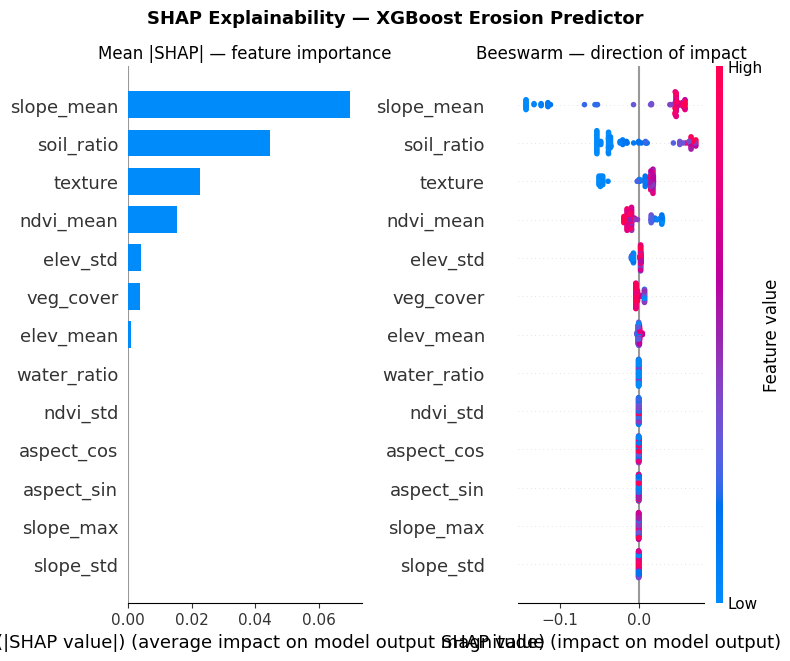

✅ SHAP analysis saved!


In [ ]:
print('Computing SHAP values for XGBoost...')
explainer  =shap.TreeExplainer(xgb_model)
shap_values=explainer.shap_values(X_test_s)

fig,axes=plt.subplots(1,2,figsize=(16,6))
fig.suptitle('SHAP Explainability — XGBoost Erosion Predictor',fontsize=13,fontweight='bold')

plt.sca(axes[0])
shap.summary_plot(shap_values,X_test_s,feature_names=FEATURE_COLS,plot_type='bar',show=False)
axes[0].set_title('Mean |SHAP| — feature importance')

plt.sca(axes[1])
shap.summary_plot(shap_values,X_test_s,feature_names=FEATURE_COLS,show=False)
axes[1].set_title('Beeswarm — direction of impact')

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/shap_analysis.png',dpi=150,bbox_inches='tight')
plt.show()
print('✅ SHAP analysis saved!')


---
## 🗺️ Step 12 — Erosion Risk Mosaic

Predicting erosion scores: 100%|██████████| 200/200 [00:03<00:00, 53.38it/s]


✅ 200 predictions done
   Mean: 0.580  Max: 0.769
   High risk: 58 patches


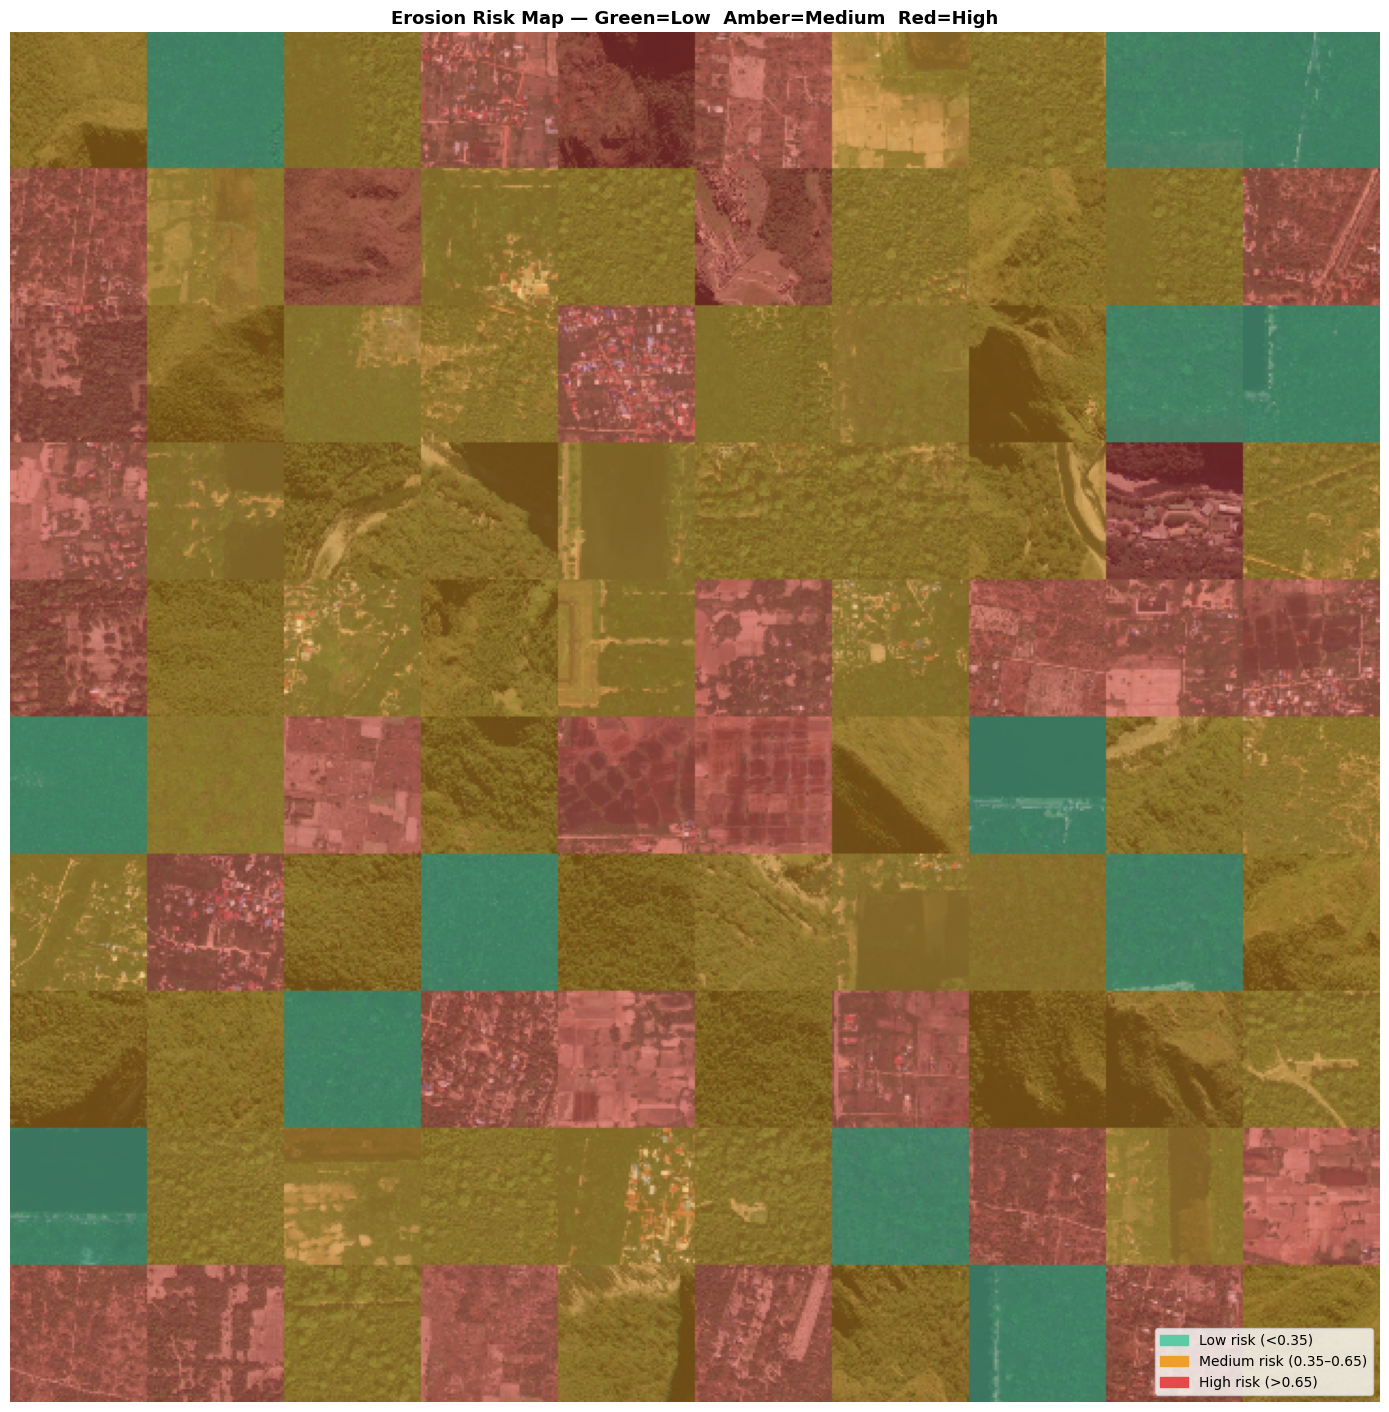

✅ Mosaic saved!


In [ ]:
def score_to_color(score):
    if score<0.35: return (92,202,165)
    elif score<0.65: return (239,159,39)
    else: return (226,75,74)

all_scores=[]; all_paths=[]
for p in tqdm(all_img_paths[:200],desc='Predicting erosion scores'):
    feats=extract_terrain_features(p)
    if feats is None: continue
    fv=np.array([[feats[f] for f in FEATURE_COLS]])
    fv=imputer.transform(fv); fv=scaler.transform(fv)
    score=float(np.clip(xgb_model.predict(fv)[0],0,1))
    all_scores.append(score); all_paths.append(p)

print(f'✅ {len(all_scores)} predictions done')
print(f'   Mean: {np.mean(all_scores):.3f}  Max: {np.max(all_scores):.3f}')
print(f'   High risk: {sum(1 for s in all_scores if s>0.65)} patches')

THUMB=64; N=min(len(all_paths),100); cols=10; rows=(N+cols-1)//cols
mosaic=np.zeros((rows*THUMB,cols*THUMB,3),dtype=np.uint8)
for idx in range(N):
    img=cv2.imread(all_paths[idx])
    if img is None: continue
    img=cv2.resize(img,(THUMB,THUMB))
    img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    color=score_to_color(all_scores[idx])
    overlay=np.full_like(img,color,dtype=np.uint8)
    img=cv2.addWeighted(img,0.55,overlay,0.45,0)
    r,c=divmod(idx,cols)
    mosaic[r*THUMB:(r+1)*THUMB,c*THUMB:(c+1)*THUMB]=img

fig,ax=plt.subplots(figsize=(14,rows*1.5))
ax.imshow(mosaic)
ax.set_title('Erosion Risk Map — Green=Low  Amber=Medium  Red=High',fontsize=13,fontweight='bold')
ax.axis('off')
legend=[mpatches.Patch(color=(92/255,202/255,165/255),label='Low risk (<0.35)'),
        mpatches.Patch(color=(239/255,159/255,39/255), label='Medium risk (0.35–0.65)'),
        mpatches.Patch(color=(226/255,75/255,74/255),  label='High risk (>0.65)')]
ax.legend(handles=legend,loc='lower right',fontsize=10)
plt.tight_layout()
plt.savefig(f'{MAP_DIR}/erosion_risk_mosaic.png',dpi=150,bbox_inches='tight')
plt.show()
print('✅ Mosaic saved!')


---
## 🌐 Step 13 — Interactive Folium Map

In [ ]:
CENTER_LAT=20.0; CENTER_LON=78.0; GRID_STEP=0.005
m=folium.Map(location=[CENTER_LAT,CENTER_LON],zoom_start=13,tiles='CartoDB positron')

title_html='<div style="position:fixed;top:10px;left:50px;z-index:9999;'\
    'background:white;padding:10px;border-radius:8px;border:2px solid #ccc;'\
    'font-size:14px;font-weight:bold;">Terrain Erosion Risk Map</div>'
m.get_root().html.add_child(folium.Element(title_html))

RISK_COLORS={0:'#5DCAA5',1:'#EF9F27',2:'#E24B4A'}
RISK_LABELS={0:'Low',1:'Medium',2:'High'}

for idx,(path,score) in enumerate(zip(all_paths[:150],all_scores[:150])):
    lat=CENTER_LAT+(idx//15)*GRID_STEP
    lon=CENTER_LON+(idx%15)*GRID_STEP
    cls=0 if score<0.35 else (1 if score<0.65 else 2)
    folium.CircleMarker(
        location=[lat,lon],radius=8,
        color=RISK_COLORS[cls],fill=True,
        fill_color=RISK_COLORS[cls],fill_opacity=0.7,
        popup=folium.Popup(
            f'<b>Patch:</b> {Path(path).name}<br>'
            f'<b>Score:</b> {score:.3f}<br>'
            f'<b>Risk:</b> {RISK_LABELS[cls]}',max_width=200),
        tooltip=f'{RISK_LABELS[cls]} risk ({score:.2f})'
    ).add_to(m)

legend_html='<div style="position:fixed;bottom:30px;right:30px;z-index:9999;'\
    'background:white;padding:12px;border-radius:8px;border:2px solid #ccc;'\
    'font-size:13px;"><b>Erosion Risk</b><br>'\
    '<span style="color:#5DCAA5">&#9679;</span> Low (&lt;0.35)<br>'\
    '<span style="color:#EF9F27">&#9679;</span> Medium (0.35–0.65)<br>'\
    '<span style="color:#E24B4A">&#9679;</span> High (&gt;0.65)</div>'
m.get_root().html.add_child(folium.Element(legend_html))

map_path=f'{MAP_DIR}/erosion_risk_map.html'
m.save(map_path)
print(f'✅ Interactive map saved: {map_path}')
from IPython.display import IFrame,display
display(IFrame(map_path,width='100%',height='480px'))


✅ Interactive map saved: /content/archaeological_project/milestone3/maps/erosion_risk_map.html


---
## 💾 Step 14 — Save Models, Metrics & Drive Backup

In [ ]:
import pickle, shutil

# ── Save models locally ────────────────────────────────────
pickle.dump(rf_model,  open(f'{MODEL_DIR}/random_forest.pkl','wb'))
pickle.dump(xgb_model, open(f'{MODEL_DIR}/xgboost.pkl',      'wb'))
pickle.dump(scaler,    open(f'{MODEL_DIR}/scaler.pkl',        'wb'))
pickle.dump(imputer,   open(f'{MODEL_DIR}/imputer.pkl',       'wb'))
print('✅ Models saved locally!')

# ── Save metrics ───────────────────────────────────────────
m3_metrics={
    'milestone':3,'features':FEATURE_COLS,'n_samples':len(df),
    'random_forest':{'test_rmse':round(rf_test_rmse,4),'test_mae':round(rf_test_mae,4),
                     'test_r2':round(rf_test_r2,4),'oob_score':round(rf_model.oob_score_,4)},
    'xgboost':{'test_rmse':round(xgb_test_rmse,4),'test_mae':round(xgb_test_mae,4),
               'best_iter':int(getattr(xgb_model,'best_iteration',0))},
    'best_model':best_model_name,'map_path':map_path,
}
m3_path=f'{M3_DIR}/milestone3_metrics.json'
with open(m3_path,'w') as f: json.dump(m3_metrics,f,indent=2)
print('✅ Metrics saved:', m3_path)

# ── Backup EVERYTHING to Google Drive ─────────────────────
DRIVE_M3_OUT = '/content/drive/MyDrive/Archaeological_AI/Milestone3_Output'
os.makedirs(DRIVE_M3_OUT, exist_ok=True)

# Copy result images and map
for fn in (glob.glob(f'{RESULTS_DIR}/*') +
           glob.glob(f'{MAP_DIR}/*') + [m3_path]):
    if os.path.isfile(fn): shutil.copy2(fn, DRIVE_M3_OUT)

# CRITICAL: copy pkl model files so M4 can find them
for mdl in ['random_forest.pkl','xgboost.pkl','scaler.pkl','imputer.pkl']:
    mp = f'{MODEL_DIR}/{mdl}'
    if os.path.exists(mp):
        shutil.copy2(mp, DRIVE_M3_OUT)
        print(f'  ✅ {mdl} → Drive')
    else:
        print(f'  ⚠️  {mdl} not found')

print(f'\n✅ M3 backup complete: {DRIVE_M3_OUT}')
print('   Files in Drive M3 folder:')
for fn in glob.glob(f'{DRIVE_M3_OUT}/**/*', recursive=True):
    if os.path.isfile(fn): print(f'   • {fn[len(DRIVE_M3_OUT):]}')
print()
print(json.dumps(m3_metrics,indent=2))


✅ Models saved locally!
✅ Metrics saved: /content/archaeological_project/milestone3/milestone3_metrics.json
  ✅ random_forest.pkl → Drive
  ✅ xgboost.pkl → Drive
  ✅ scaler.pkl → Drive
  ✅ imputer.pkl → Drive

✅ M3 backup complete: /content/drive/MyDrive/Archaeological_AI/Milestone3_Output
   Files in Drive M3 folder:
   • /correlation_heatmap.png
   • /eda_terrain.png
   • /erosion_risk_map.html
   • /model_evaluation.png
   • /imputer.pkl
   • /scaler.pkl
   • /shap_analysis.png
   • /erosion_risk_mosaic.png
   • /random_forest.pkl
   • /milestone3_metrics.json
   • /xgboost.pkl

{
  "milestone": 3,
  "features": [
    "slope_mean",
    "slope_std",
    "slope_max",
    "aspect_sin",
    "aspect_cos",
    "ndvi_mean",
    "ndvi_std",
    "elev_mean",
    "elev_std",
    "texture",
    "veg_cover",
    "soil_ratio",
    "water_ratio"
  ],
  "n_samples": 437,
  "random_forest": {
    "test_rmse": 0.015,
    "test_mae": 0.0105,
    "test_r2": 0.992,
    "oob_score": 0.986
  },
  "xgboos

---
## ✅ Milestone 3 Complete!
| Step | Task | Score |
|------|------|-------|
| 3 | Feature extraction (13 features) | ✅ |
| 4 | Build feature dataset | ✅ |
| 5 | Generate erosion labels | ✅ |
| 6 | EDA + correlation heatmap | ✅ |
| 7 | Train/Val/Test split + scaling | ✅ |
| 8 | Train Random Forest | **RMSE, MAE, R²** |
| 9 | Train XGBoost (early stopping) | **RMSE, MAE, R²** |
| 10 | Model comparison + plots | ✅ |
| 11 | SHAP explainability | ✅ |
| 12 | Erosion risk mosaic | ✅ |
| 13 | Interactive Folium map | ✅ |
| 14 | Save models + Drive backup | ✅ |
